importiamo tutto ciò che ci serve

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
from scipy.stats import boxcox, zscore
from scipy.special import inv_boxcox

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV

from sklearn.cluster import KMeans

Carichiamo il dataset

In [17]:
df = pd.read_csv("marketing_campaign.csv", sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Descriviamo le analisi statistiche dei valori numerici del dataset arrotondando a 2 valori decimali e trasponendo il dataframe.

In [19]:
df.describe(include='number').round(2).T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.16,3246.66,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.81,11.98,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.25,25173.08,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.44,0.54,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.51,0.54,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0


Facciamo la stessa cosa per i valori non numerici

In [20]:
df.describe(include='object').round(2).T

,count,unique,top,freq
Education,2240,5,Graduation,1127
Marital_Status,2240,8,Married,864
Dt_Customer,2240,663,31-08-2012,12


Troviamo la quantità di valori nulli per colonna

In [21]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Troviamo il numero delle righe duplicate

In [22]:
print('Il numero di righe duplicate nel dataset è:', df.duplicated().sum())

Il numero di righe duplicate nel dataset è: 0


Da tutto ciò si evince che:
il dataset ha 2240 osservazioni per 29 colonne.

possiamo eliminare le colonne non necessarie, come id (inutile valutare), Z_COstContact e Z_Revenue(potrebbero essere i derivati di una scalarizzazione di altri valori) e Response(potrebbe essere un risultato di un altro algoritmo precedentemente applicato).

C'è solo una colonna con valori nulli - il reddito.

La maggior parte delle colonne sono numeriche e Dt_customer dovrebbe essere convertito in un datetime.

Sono presenti outliers in alcune colonne (si evince da una dev std alta)


Puliamo i dati iniziando droppando le righe con valori null

In [23]:
df.dropna(inplace=True)

Droppiamo le colonne che non sono necessarie

In [24]:
df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue','Response'], inplace=True)

Calcoliamo l'età attuale dei clienti prendendo in considerazione la loro data di nascita sottraendola alla data di registrazione di un cliente più recente.

In [25]:
df['Dt_Customer'] = pd.to_datetime(df.Dt_Customer, format="%d-%m-%Y")
last_date = df['Dt_Customer'].max()
df['Days_is_client'] = (last_date - df['Dt_Customer']).dt.days

df['Cus_Age'] = (last_date.year - df['Year_Birth'])

df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Days_is_client,Cus_Age
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,4,7,0,0,0,0,0,0,663,57
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,2,5,0,0,0,0,0,0,113,60
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,10,4,0,0,0,0,0,0,312,49
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,4,6,0,0,0,0,0,0,139,30
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,6,5,0,0,0,0,0,0,161,33


Ora possiamo anche eliminare le colonne relative alla data di nascita e alla data di registrazione dei clienti

In [26]:
df.drop(columns = ['Year_Birth', 'Dt_Customer'], inplace = True)

puliamo i dati testuali rinominandoli

In [27]:
df['Education'].replace({'PhD': 'Postgraduate',
                        'Master': 'Postgraduate',
                         'Graduation': 'Graduate',
                         '2n Cycle': 'Graduate',
                         'Basic': 'Undergraduate'
                        }, inplace=True)

df['Marital_Status'].replace({'Married': 'Partner',
                        'Together': 'Partner',
                         'Single': 'Single',
                         'Divorced': 'Single',
                         'Widow': 'Single',
                         'Alone': 'Single',
                         'Absurd': 'Single',
                         'YOLO': 'Single'
                        }, inplace=True)

Creiamo delle nuove colonna che rappresenta il totale delle spese

In [28]:
df['Expenses'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Days_is_client,Cus_Age,Expenses
0,Graduate,Single,58138.0,0,0,58,635,88,546,172,...,7,0,0,0,0,0,0,663,57,1617
1,Graduate,Single,46344.0,1,1,38,11,1,6,2,...,5,0,0,0,0,0,0,113,60,27
2,Graduate,Partner,71613.0,0,0,26,426,49,127,111,...,4,0,0,0,0,0,0,312,49,776
3,Graduate,Partner,26646.0,1,0,26,11,4,20,10,...,6,0,0,0,0,0,0,139,30,53
4,Postgraduate,Partner,58293.0,1,0,94,173,43,118,46,...,5,0,0,0,0,0,0,161,33,422


Combiniamo le colonne dove possibile.

In [29]:
df['Kids'] = df['Kidhome'] + df['Teenhome']

df['TotalAcceptedCmp'] = df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5']

df['TotalNumPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumDealsPurchases']

data = df.copy()

Salviamo in una lista le colonne di maggior interesse e con queste creiamo un nuovo dataframe

In [31]:
necessary_columns = ['Education', 'Marital_Status', 'Income', 'Kids', 'Days_is_client', 'Recency', 'Expenses', 'Cus_Age',
                 'TotalNumPurchases', 'TotalAcceptedCmp', 'Complain']

df = df[necessary_columns]
df.head()

,Education,Marital_Status,Income,Kids,Days_is_client,Recency,Expenses,Cus_Age,TotalNumPurchases,TotalAcceptedCmp,Complain
0,Graduate,Single,58138.0,0,663,58,1617,57,25,0,0
1,Graduate,Single,46344.0,2,113,38,27,60,6,0,0
2,Graduate,Partner,71613.0,0,312,26,776,49,21,0,0
3,Graduate,Partner,26646.0,1,139,26,53,30,8,0,0
4,Postgraduate,Partner,58293.0,1,161,94,422,33,19,0,0


Categorizziamo le nuove colonne in base a se sono booleane, numeriche, testuali

In [32]:
binary_columns = [col for col in df.columns if df[col].nunique() == 2]
categorical_columns = [col for col in df.columns if 2 < df[col].nunique() < 10]
numerical_columns = [col for col in df.select_dtypes(include=['number']).columns 
                     if col not in binary_columns + categorical_columns]

Troviamo gli outliers con ZScore. ZScore è una funzione di scipy che punto per punto applica questa formula:
$$
z = \frac{x - \mu}{\sigma}
$$
Se la z sarà maggiore di 3 o minore di -3 il punto sarà considerato un outlier.
​Identifichiamoli per eliminarli
 


In [33]:
z_scores = pd.DataFrame(zscore(df[numerical_columns]), columns = numerical_columns)
z_scores
outliers = z_scores[(np.abs(z_scores) > 3).any(axis=1)]
outliers

df = df.drop(outliers.index)


?

In [34]:
# numerical_columns
binary_columns + categorical_columns

['Marital_Status', 'Complain', 'Education', 'Kids', 'TotalAcceptedCmp']

Visualizziamo la funzione di densità per ogni colonna

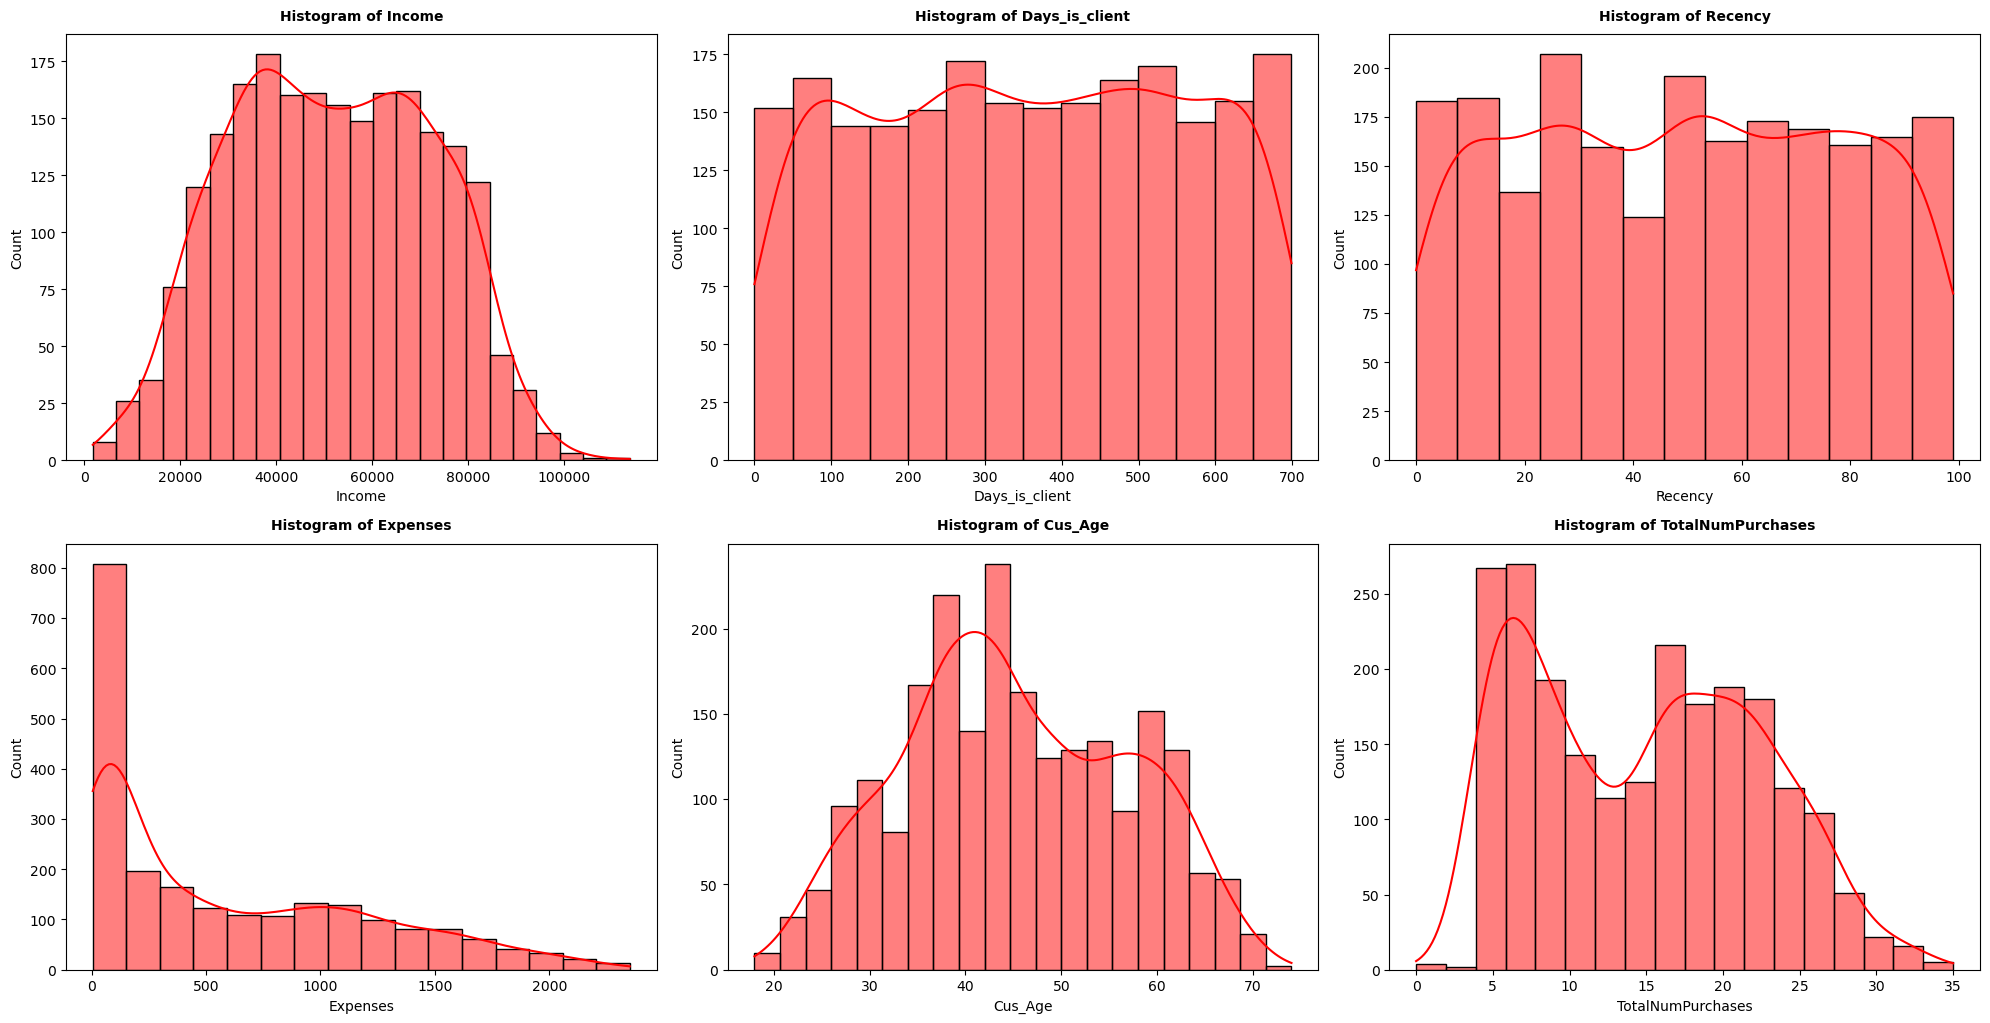

In [35]:
x=1
#impostiamo la dimensione della figura
plt.figure(figsize=(20,15))
for col in numerical_columns:
    plt.subplot(len(numerical_columns)//2, len(numerical_columns)//2, x) # dividiamo la figura in una griglia
    sns.histplot(data=df, x=col, kde=True, color='red') # otteniamo la funzione di densità dell'elemento corrente
    plt.title(f'Histogram of {col}', pad=10, fontweight='bold', fontsize=10)
    plt.tight_layout()
    x+=1

plt.show()

Usiamo la funzione countplot per tracciare un grafico a barre che mostra la frequenza di ogni categoria in una colonna del dataframe, in pratica visualizziamo la frequenza di ciascun valore in una colonna

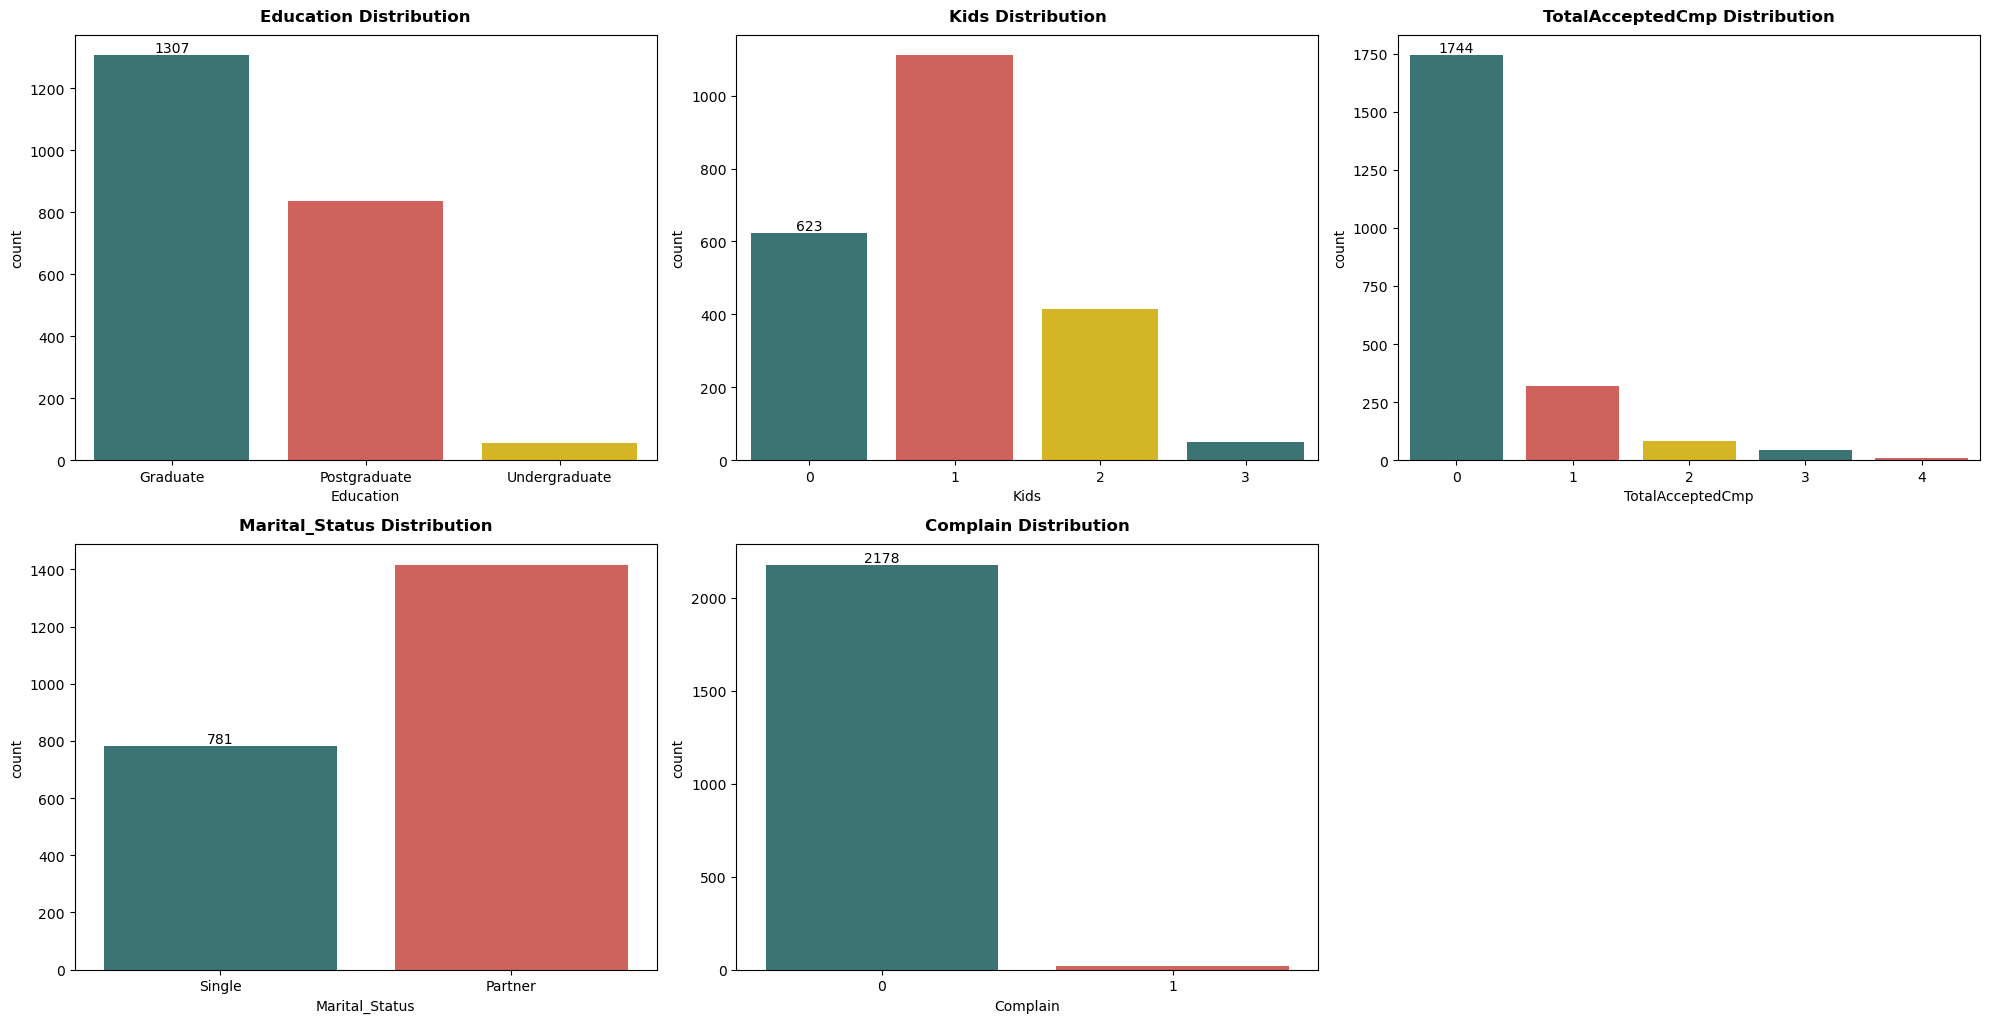

In [36]:
# Define the color palette
custom_palette = ["#327D7C", "#E2504A", "#F0C808"]

x=1
plt.figure(figsize=(20,15))
for col in categorical_columns + binary_columns:
    plt.subplot(3,3,x)
    ax=sns.countplot(data=df, x=col, palette=custom_palette)
    plt.title(f"{col} Distribution",pad=10,fontweight="bold",fontsize=12)
    ax.bar_label(ax.containers[0])
    plt.tight_layout()
    x+=1

plt.show()
    

Mostriamo la correlazione tra le colonne attraverso una heatmap.

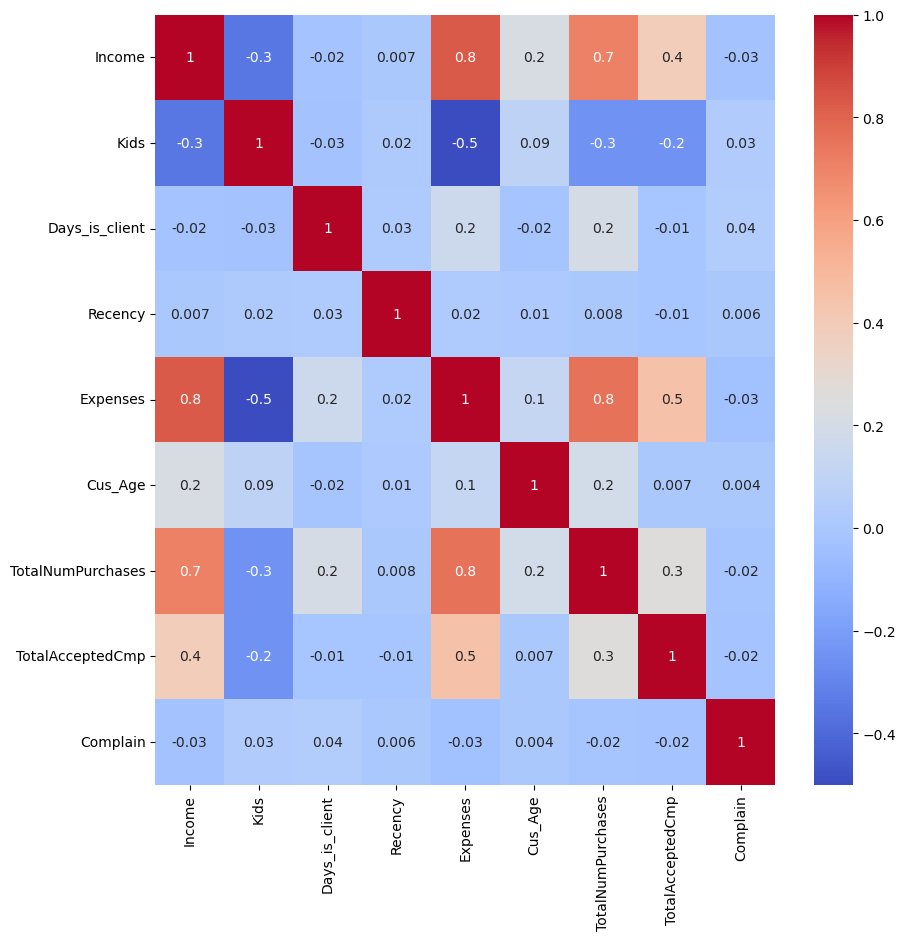

In [37]:
colors = ["#E2504A", "#EDEBEC", "#327D7C"]

corr_matrix = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,10))
sns.heatmap(data=corr_matrix, annot=True, color=colors, cmap='coolwarm', fmt=".1g")
plt.show()

Da tutto ciò si evince che:
Il reddito successivamente alla rimozione degli outlier segue una distribuzione normale.
Le date in cui i clienti si sono registrti e l'ultimo accesso sono molto variegate.
I clienti acqustano prodotti economici poiché l'expenses distribution presenta una funzione esponenziale.
Il numero totale di acquisti riflette una funzione binomiale perché a ogni visita il cliente potrebbe acquistare o non acquistare un determinato prodotto e nel caso specifico ci dice che ci sono un numero di acquisti predominanti per cliente.
La maggior parte dei clienti sono laureati con un figlio, hanno un partner, non hanno chiesto rimborsi negli ultimi due anni, e non sono interessati alle offerte.
Il reddito, le spese e il numero totale di acquisti sono fortemente correlati tra di loro.

Rendiamo i valori categorici dei valori numerici per lavorarci. standardizziamo tutti i valori.

In [38]:
df_copy = df.copy()

categorical_columns = df_copy.select_dtypes(include='object').columns.tolist()

x_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True, dtype=int) 

x_encoded.info()

scale = StandardScaler()

x_scaled = scale.fit_transform(x_encoded)

x_scaled.shape

<class 'pandas.core.frame.DataFrame'>
Index: 2198 entries, 0 to 2239
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2198 non-null   float64
 1   Kids                     2198 non-null   int64  
 2   Days_is_client           2198 non-null   int64  
 3   Recency                  2198 non-null   int64  
 4   Expenses                 2198 non-null   int64  
 5   Cus_Age                  2198 non-null   int64  
 6   TotalNumPurchases        2198 non-null   int64  
 7   TotalAcceptedCmp         2198 non-null   int64  
 8   Complain                 2198 non-null   int64  
 9   Education_Postgraduate   2198 non-null   int32  
 10  Education_Undergraduate  2198 non-null   int32  
 11  Marital_Status_Single    2198 non-null   int32  
dtypes: float64(1), int32(3), int64(8)
memory usage: 197.5 KB


(2198, 12)

Usiamo il k-means per classificare i clienti. Per inizializzare i centroidi usiamo il metodo k-means++, quindi non verranno scelti casualmente, ad eccezione del primo. Inoltre inizializziamo la variabile che ci permetterà di calcolare l'inerzia.

In [39]:
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans.fit(x_scaled)
y_kmeans = kmeans.fit_predict(x_scaled)
inertia = kmeans.inertia_

Proviamo con diversi numeri di cluster a calcolare l'inerzia per trovare il numero più adatto. L'obiettivo del k-means è minimizzare appunto l'inerzia, ovvero la distanza euclidea tra ogni punto del cluster e il relativo centroide. L'inerzia è data dalla seguente formula: 
$$
\text{Inertia} = \sum_{i=1}^{n} \sum_{k=1}^{K} \mathbf{1}(y_i = k) \cdot ||x_i - \mu_k||^2
$$


In [40]:
kmeans_inertias = []

for n in np.arange(1,10,1):
    kmeans = KMeans(n_clusters=n, init='k-means++', n_init=10, max_iter=300, random_state=42)
    kmeans.fit(x_scaled)
    inertia = kmeans.inertia_
    kmeans_inertias.append(inertia)

Rappresentiamo graficamente l'inerzia per ogni cluster.

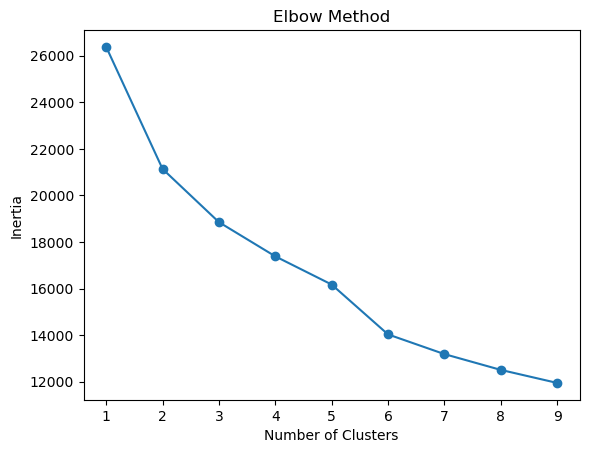

In [41]:
# Plotting the elbow curve
plt.plot(np.arange(1,10,1), kmeans_inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

Oltre all'inerzia, per valutare la correttezza di un algoritmo di clustering nel raggruppare i dati possiamo usare la Silhouette Score, la quale misura quanto un punto sia ben assegnato al relativo cluster con la seguente formula:
$$
S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$


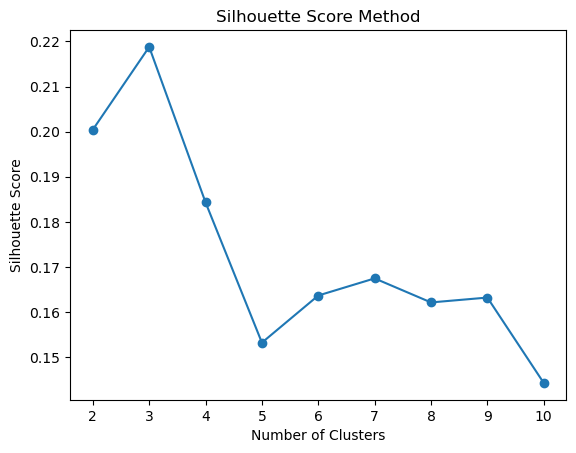

In [42]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    kmeans.fit(x_scaled)
    score = silhouette_score(x_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the silhouette scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

Se osserviamo il grafico dell'inerzia possiamo notare che dopo che i cluster sono pari a 2 l'inerzia non scende più così significativamente, mentre nel secondo metodo il grafico ci suggerisce che il numero di cluster ideale è 3, quindi lo usiamo per il numero di cluster effettivo per il k-means.

In [43]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans_final.fit(x_scaled)
y_label = kmeans_final.labels_
y_kmeans = kmeans_final.fit_predict(x_scaled)
print(kmeans_final.inertia_)

18851.020312646757


Riportiamo i dati alla condizione originale, quindi precedente alla standardizzazione per visualizzare il risultato.

In [44]:
x_original = scale.inverse_transform(x_scaled)
df_clusters = df.copy()
df_clusters['Cluster'] = y_kmeans
df_clusters.head()

,Education,Marital_Status,Income,Kids,Days_is_client,Recency,Expenses,Cus_Age,TotalNumPurchases,TotalAcceptedCmp,Complain,Cluster
0,Graduate,Single,58138.0,0,663,58,1617,57,25,0,0,0
1,Graduate,Single,46344.0,2,113,38,27,60,6,0,0,1
2,Graduate,Partner,71613.0,0,312,26,776,49,21,0,0,0
3,Graduate,Partner,26646.0,1,139,26,53,30,8,0,0,1
4,Postgraduate,Partner,58293.0,1,161,94,422,33,19,0,0,1


Visualizziamo il grafico a dispersione del cluster dei clienti

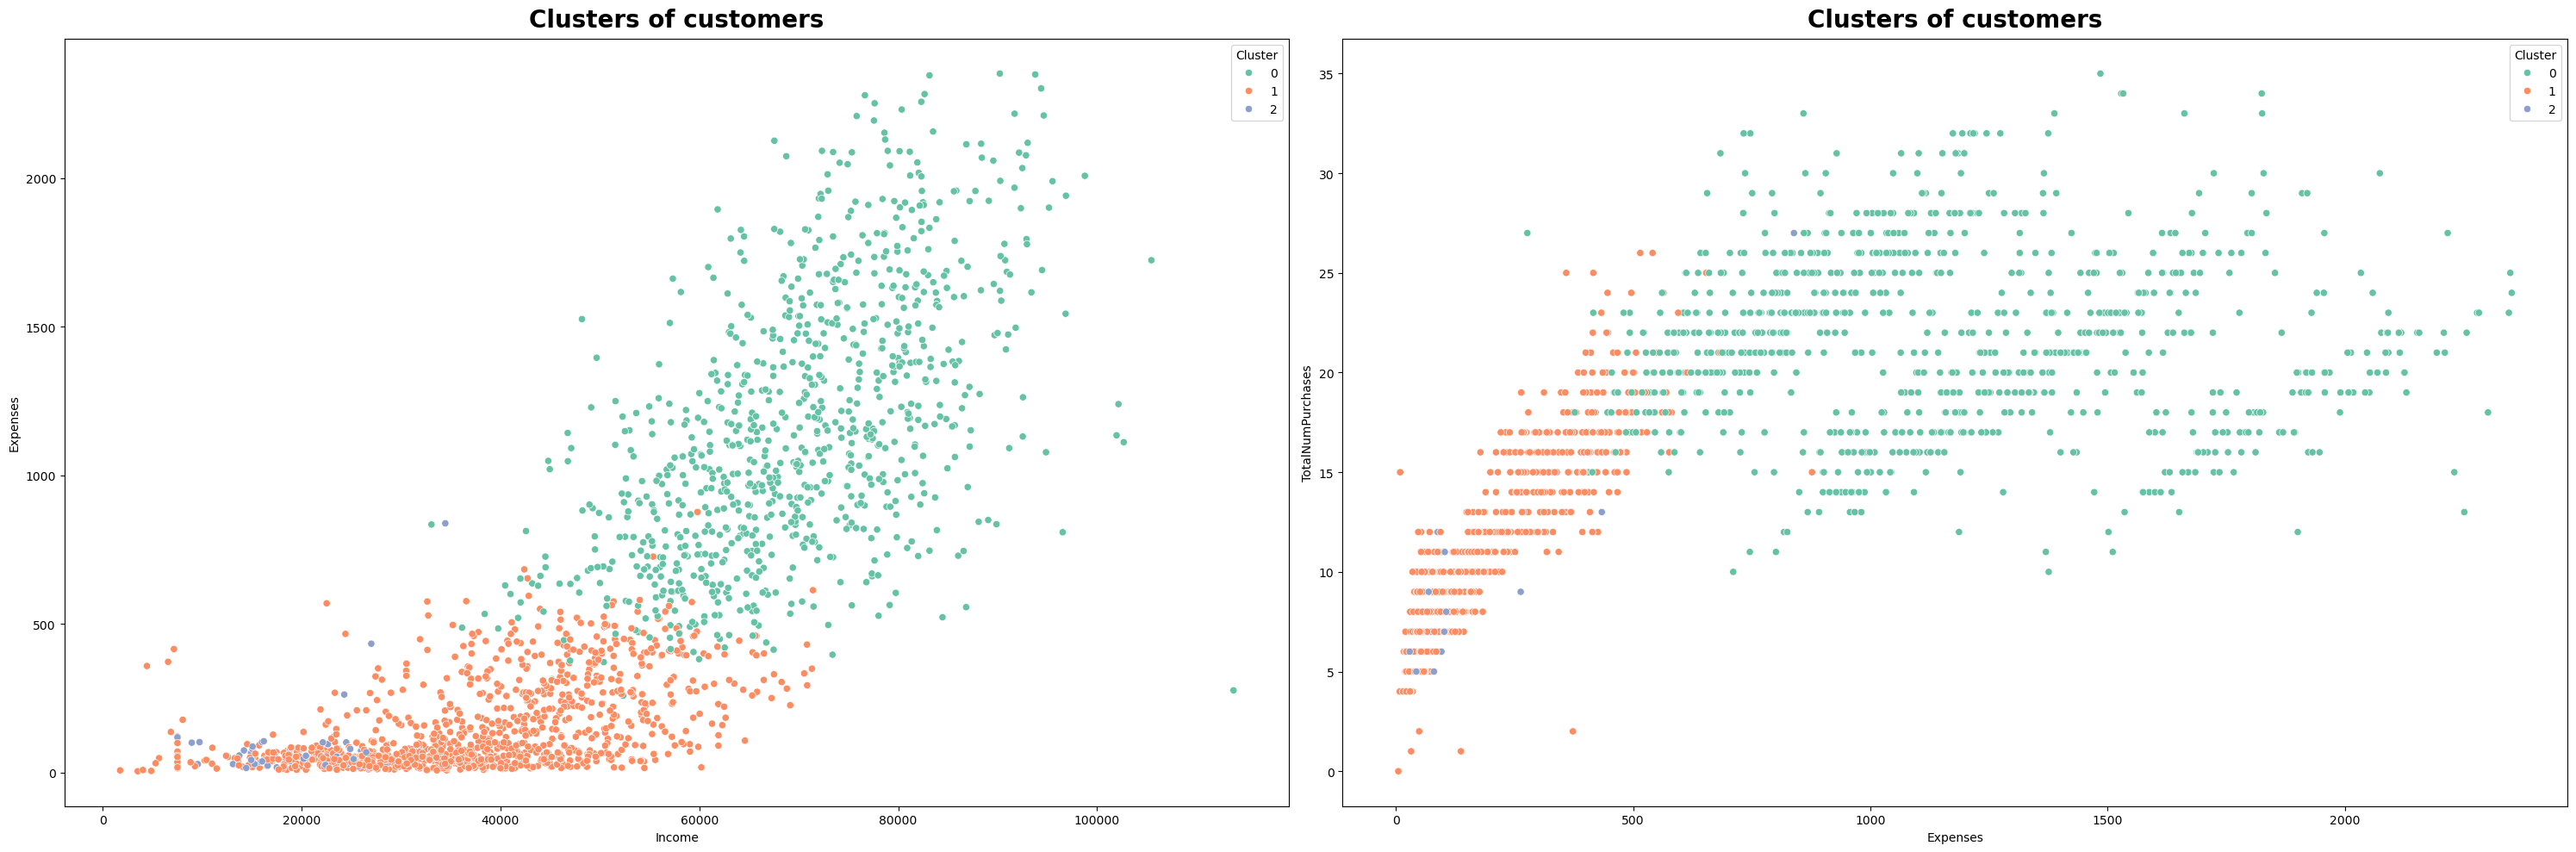

In [45]:
plt.figure(figsize=(30,10))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clusters, x='Income', y='Expenses', hue='Cluster', palette='Set2')
plt.title('Clusters of customers',fontsize = 20, fontweight='bold', pad=10)

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clusters, x='Expenses', y='TotalNumPurchases', hue='Cluster', palette='Set2')
plt.title('Clusters of customers',fontsize = 20, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

Visualizziamo i boxplot di tutti i cluster

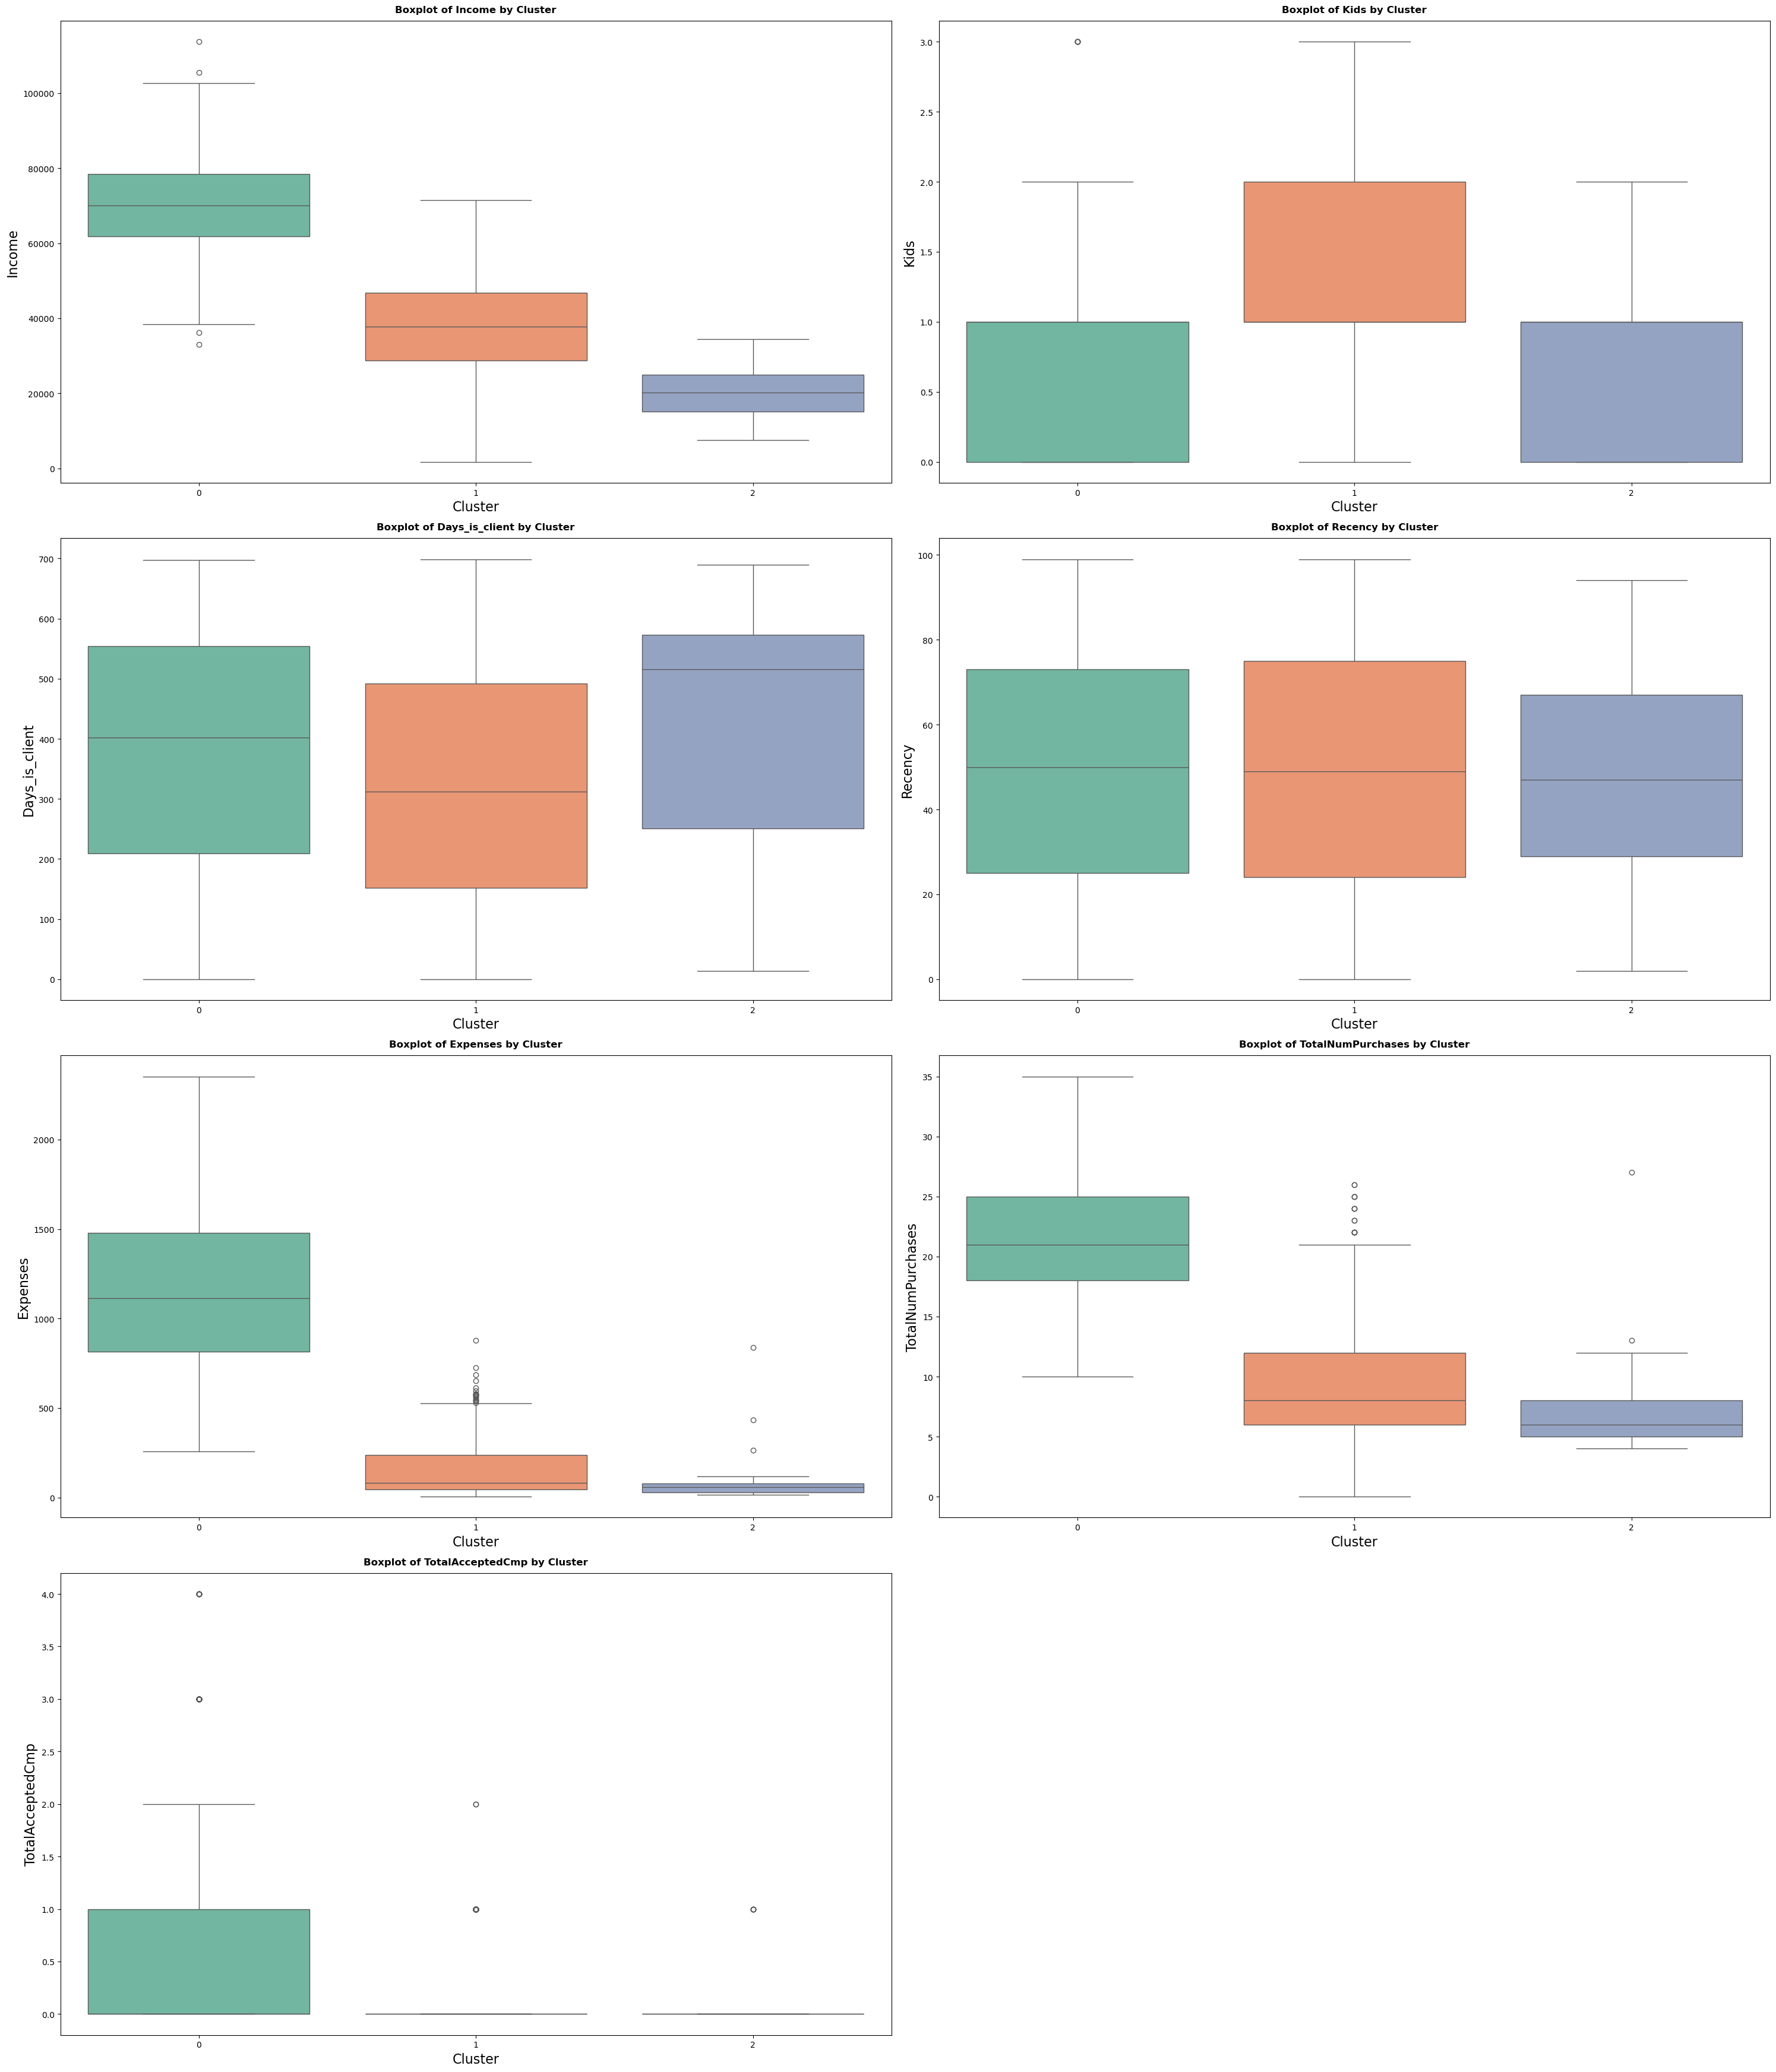

In [51]:
plt.figure(figsize=(30,35))
x = 1
for col in columns_to_plot:
    plt.subplot(4, 2, x)
    sns.boxplot(data=df_clusters.drop_duplicates(), x='Cluster', y=col, palette='Set2')
    plt.title(f'Boxplot of {col} by Cluster', pad=10, fontweight='bold', fontsize=12)
    plt.xlabel('Cluster', fontsize=16)
    plt.ylabel(f"{col}", fontsize=16)
    plt.tight_layout()
    x += 1
plt.show()